# 🏔️ Alpine Signal Radar — Opportunity Dashboard

A **scenario-driven** retail opportunity radar. Pitched on Swiss outdoor, but the engine is generic — every retailer/community/market specific lives in `config/scenarios/*.yaml`, not in code.

**Pipeline:** signals → normalize → dedup → score → transfer (CH/DACH) → action.  
Run `python -m src.collect_offline` then `python -m src.pipeline` to refresh the artifacts this notebook reads. *(Claude enrichment is used if `ANTHROPIC_API_KEY` is set; otherwise a deterministic fallback runs.)*

In [1]:
# Setup — switch SCENARIO to render any profile
import os, sys
# run from repo root so `src` imports and relative artifact paths resolve
while not os.path.isdir('src'):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from src import report

SCENARIO = 'swiss_outdoor'
opps, summary = report.load_results(SCENARIO)
scn = report.get_scenario(SCENARIO)
ranked = sorted(report.live(opps), key=lambda o: o['final_score'], reverse=True)
f"{len(opps)} opportunities — {len(ranked)} surfaced, {len(report.dead(opps))} discarded"

'17 opportunities — 14 surfaced, 3 discarded'

## 1. Executive summary

In [2]:
display(Markdown(summary))

# Swiss Outdoor Retail — Opportunity Summary

The strongest CH transfer opportunities are filter-flask hydration and PFAS-free repairable shells, where rising local relevance, EU availability, and clear coverage gaps support immediate buys. Challenger trail brands are a high-legitimacy play worth securing distribution for ahead of the nearby UTMB 2026 visibility spike. Single-vessel filtration, smarter-light packs, women's gravel gear, and gorpcore apparel merit pilots, with gorpcore framed as functional luxe bridged by Salomon/Arc'teryx collabs. Hydration bladders, legacy PFAS hardshells, and maximalist stack shoes are cooling and should be held and cleared, while the TikTok gimmick and embellished logo-mania outerwear are watch-only with no functional or legitimacy basis for CH.


## 2. Ranked opportunities
Coloured by confidence (multi-source + local gap → high).

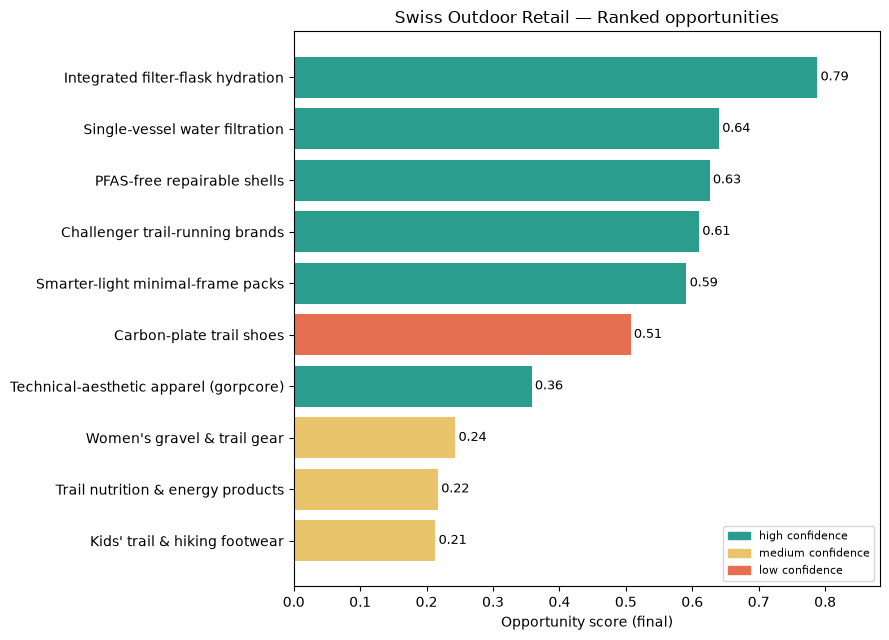

In [3]:
report.plot_ranked(opps, scn); plt.show()

## 3. Hero opportunity
The #1 signal-to-shelf gap, with its 5-dimension transfer profile.

### 🥇 Integrated filter-flask hydration

⭐ Trendsetter-backed (Salomon)

**Swiss transfer score:** 79/100 · **Confidence:** high · **Coverage:** absent · **Final score:** 0.79

**Why now:** US/UK/KR momentum is accelerating while CH search stays flat, opening a clean first-mover transfer window in an absent local category.

**Transferability:** EU availability via Bergfreunde and Salomon's DACH presence make CH transfer low-friction, though CH legitimacy rests on race/forum proof rather than UTMB results yet.

**Recommended action:** Buy a focused Salomon filter-flask range now and seed it via CH trail-running clubs ahead of summer season.

**Risks:** Filter cleaning/longevity skepticism and a still-forming legitimacy base could slow conversion.

**Evidence:**
- **community forum**: [r/Ultralight](https://reddit.com/r/Ultralight), [r/trailrunning](https://reddit.com/r/trailrunning)
- **competitor assortment**: [Bergfreunde](https://www.bergfreunde.de/filter-flask/), [REI](https://www.rei.com/search?q=filter%20flask)
- **search trends**: [Google Trends](https://trends.google.com/trends/explore?q=filter%20flask&geo=CH), [Google Trends](https://trends.google.com/trends/explore?q=filter%20flask&geo=GB), [Google Trends](https://trends.google.com/trends/explore?q=filter%20flask&geo=KR), [Google Trends](https://trends.google.com/trends/explore?q=filter%20flask&geo=US)

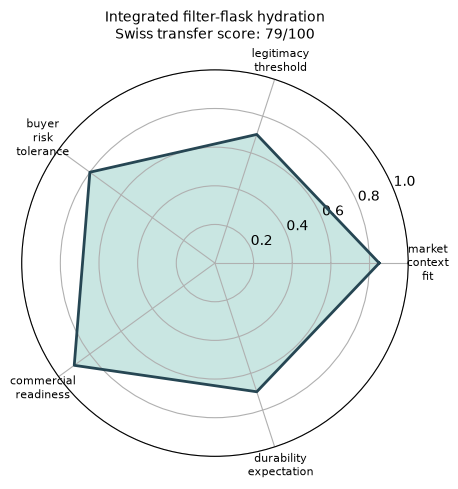

In [4]:
hero = ranked[0]
display(Markdown(report.hero_markdown(hero, scn)))
report.transfer_radar(hero, scn); plt.show()

## 4. Blank shelf — who stocks it?
Reference retailers (origin markets) vs local CH competitors. `✓` stocked · `—` absent locally (= the gap) · `·` not observed.

In [5]:
display(report.blank_shelf_table(opps, scn))

,REI (ref),Bergfreunde (ref),Transa (CH),Ochsner Sport (CH),Galaxus (CH)
opportunity,,,,,
Integrated filter-flask hydration,✓,✓,—,—,—
Single-vessel water filtration,✓,·,—,—,—
PFAS-free repairable shells,·,✓,✓,—,—
Challenger trail-running brands,✓,·,—,—,—
Smarter-light minimal-frame packs,✓,✓,✓,—,—
Carbon-plate trail shoes,✓,·,✓,✓,—


## 5. Whitespace map
Velocity (rising) vs local assortment gap. **Top-right = rising AND uncovered locally = best buys.** Bubble size = opportunity score.

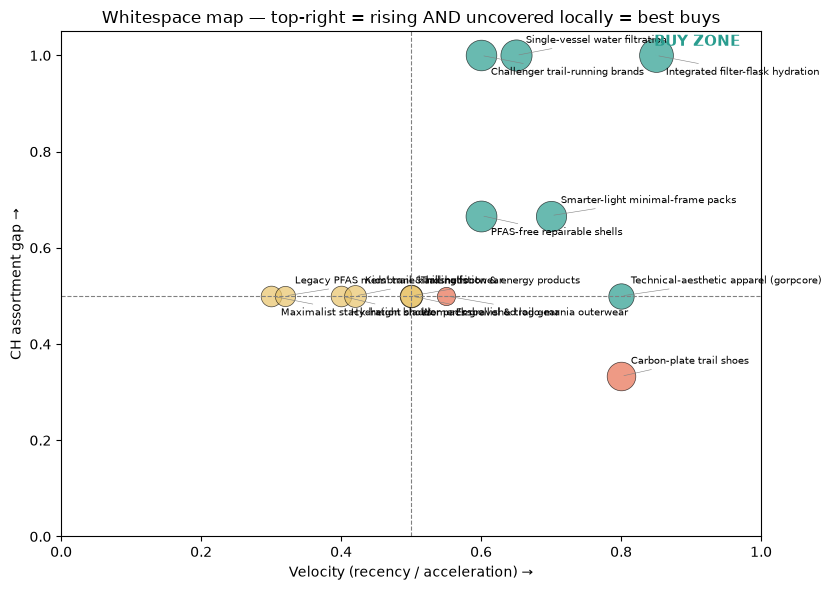

In [6]:
report.plot_whitespace(opps, scn); plt.show()

## 6. Noise graveyard
What the system **rejected**, and why — proof it has judgment, not just hype amplification.

In [7]:
display(report.graveyard_table(opps))

,why filtered out
discarded signal,
Influencer trail-apparel collab,single source type — not corroborated
TikTok viral hydration gimmick,single source type — not corroborated; transfe...
Desert-ultra race vest,single source type — not corroborated; transfe...


## 7. Cooling watchlist — *downward* early warning
Categories losing momentum in lead markets — a forward warning to hold reorders. Note the lifecycle handoff: **hydration bladders cooling as filter-flask hydration rises.**

In [8]:
display(report.cooling_table(opps))
ew = report.early_watch_table(opps)
if not ew.empty:
    print('Too soon to call (luxury/runway-only, no mass uptake yet):')
    display(ew)

,momentum,cooling score,why cooling,action
cooling signal,,,,
Hydration bladder packs,-0.35,0.175,Bladders are cooling as forums and search shif...,"Hold and run down bladder inventory, timing cl..."
Maximalist stack-height shoes,-0.29,0.144,Sentiment is cooling as runners move back towa...,Hold reorders on maximalist stack models and m...
Legacy PFAS membrane hardshells,-0.29,0.143,Legacy PFAS hardshells are declining as DACH r...,Hold and clear legacy PFAS membrane stock quic...


Too soon to call (luxury/runway-only, no mass uptake yet):


,why
too soon to call,
Embellished logo-mania outerwear,Runway/luxury-only with no mass-market uptake ...


## 8. Trendsetter Brands to Watch
Configurable brand list (luxury + prestige outdoor) **re-ranked by a computed influence score** (collab gravity · community authority · lead-time · cross-market spread · reference rank). Answers the buyer's 'which brands should we scout?'

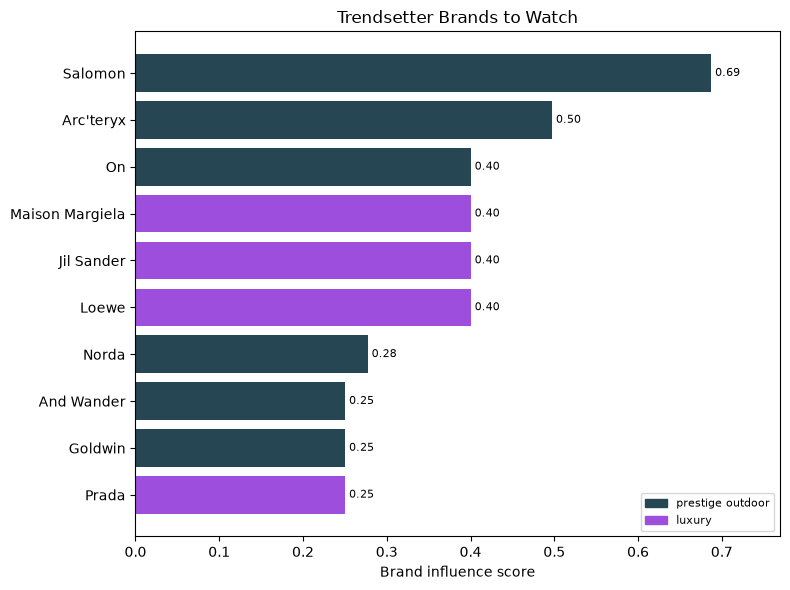

,tier,influence,why a trendsetter
brand,,,
Salomon,prestige_outdoor,0.687,Trendsetter via 1 luxury collab(s) (Maison Mar...
Arc'teryx,prestige_outdoor,0.497,Trendsetter via 1 luxury collab(s) (Jil Sander...
On,prestige_outdoor,0.400,Trendsetter via 1 luxury collab(s) (Loewe).
Maison Margiela,luxury,0.400,Trendsetter via 1 luxury collab(s) (Maison Mar...
Jil Sander,luxury,0.400,Trendsetter via 1 luxury collab(s) (Jil Sander).
Loewe,luxury,0.400,Trendsetter via 1 luxury collab(s) (Loewe).
Norda,prestige_outdoor,0.277,Trendsetter via bestseller rank at a reference...
And Wander,prestige_outdoor,0.250,NaN
Goldwin,prestige_outdoor,0.250,NaN


In [9]:
brands = report.load_brands(SCENARIO)
report.plot_trendsetters(brands); plt.show()
display(report.trendsetter_table(brands))

## 9. Within-scenario reuse — category toggle
Change `CATEGORY` to `'day_hiking'` and re-run: same engine, different category.

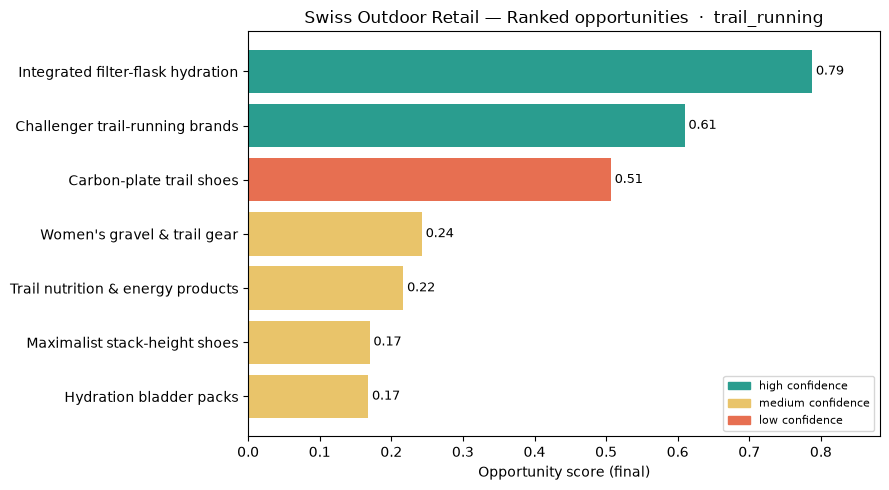

In [10]:
CATEGORY = 'trail_running'  # try 'day_hiking'
report.plot_ranked(opps, scn, category=CATEGORY); plt.show()

## 10. Cross-scenario reuse — *config, not code*
The whole product retargets to a new market/vertical by editing one YAML. Below: the live Swiss profile vs the empty template an analyst fills in.

In [11]:
from pathlib import Path
print('── swiss_outdoor.yaml (first 28 lines) ──')
print('\n'.join(Path('config/scenarios/swiss_outdoor.yaml').read_text().splitlines()[:28]))
print('\n── _template.yaml blocks an analyst fills in ──')
print('\n'.join(l for l in Path('config/scenarios/_template.yaml').read_text().splitlines() if l.strip().endswith(':') or l.startswith('# '))[:1200])

# If a second scenario has been run, show it surfaces too (cross-industry proof):
stub = Path('outputs/uk_beauty_stub/opportunities.json')
if stub.exists():
    o2, s2 = report.load_results('uk_beauty_stub')
    print(f'\nuk_beauty_stub → {len(report.live(o2))} opportunities surfaced from the SAME pipeline')
else:
    print('\n(Run: python -m src.pipeline --scenario config/scenarios/uk_beauty_stub.yaml to populate the cross-industry beat)')

── swiss_outdoor.yaml (first 28 lines) ──
scenario_id: swiss_outdoor
display_name: "Swiss Outdoor Retail"

# ─── Markets ─────────────────────────────────────────────────────────────────
target_market: CH            # where we sell
reference_markets:           # origin / early-signal markets
  - US
  - UK
  - DE
  - JP                       # Asia: major outdoor & style trend origins
  - KR                       #   (esp. for geo_style_diffusion, e.g. gorpcore)
  - CN

# ─── Local shelf reality (CH) ────────────────────────────────────────────────
local_competitors:
  - name: Transa
    url: https://www.transa.ch
    role: Premium outdoor specialist
  - name: Ochsner Sport
    url: https://www.ochsnersport.ch
    role: Mass outdoor + sport
  - name: Galaxus
    url: https://www.galaxus.ch
    role: Online breadth
    category_path: outdoor

# ─── Early commercial proof (reference retailers) ────────────────────────────
reference_retailers:

── _template.yaml blocks an analyst fills in 